# Task 2: Sentiment and Thematic Analysis

## Objective
Quantify review sentiment and identify recurring themes to uncover
satisfaction drivers and pain points for each Ethiopian bank.

## Approach
- **Sentiment Tool: VADER** — chosen for its speed and effectiveness
  on short, informal text like app reviews. Produces compound scores
  from -1 (most negative) to +1 (most positive).
- **Thematic Analysis: TF-IDF + keyword grouping** — extracts the most
  significant terms per bank and groups them into 3-5 business-relevant themes.

## Why VADER over DistilBERT?
VADER processes 1,400+ reviews in seconds vs minutes for transformer models.
For app reviews which are short and informal, VADER performs comparably to
DistilBERT while being far more computationally efficient. We validate
VADER scores against star ratings as a quality check.

In [22]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from wordcloud import WordCloud
from textblob import TextBlob
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import word_tokenize, pos_tag
import warnings
warnings.filterwarnings('ignore')

# Download NLTK resources
for res in ['vader_lexicon', 'stopwords', 'averaged_perceptron_tagger',
            'punkt', 'wordnet', 'averaged_perceptron_tagger_eng',
            'punkt_tab']:
    nltk.download(res, quiet=True)

sia = SentimentIntensityAnalyzer()
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

os.chdir(r"C:\Users\pc\fintech-review-analytics")
plt.style.use('seaborn-v0_8-darkgrid')

# Reload the data
df = pd.read_csv("data/raw/bank_reviews_analyzed.csv")
print(f"Reloaded {len(df)} reviews")
print(df.columns.tolist())
print(df["bank"].value_counts())

Reloaded 1350 reviews
['review_id', 'review', 'rating', 'date', 'bank', 'source', 'clean_text', 'sentiment_label', 'sentiment_score', 'tb_polarity', 'tb_label', 'identified_theme']
bank
Dashen Bank                    467
Bank of Abyssinia              460
Commercial Bank of Ethiopia    423
Name: count, dtype: int64


In [23]:
df = pd.read_csv("data/raw/bank_reviews.csv")
print(f"Loaded {len(df)} reviews")
print(df["bank"].value_counts())
df.head()

Loaded 1452 reviews
bank
Bank of Abyssinia              499
Dashen Bank                    498
Commercial Bank of Ethiopia    455
Name: count, dtype: int64


,review,rating,date,bank,source
0,incredible,5,2026-05-14,Commercial Bank of Ethiopia,Google Play
1,best app for financial sector,5,2026-05-14,Commercial Bank of Ethiopia,Google Play
2,it's a good application,5,2026-05-13,Commercial Bank of Ethiopia,Google Play
3,thank you cbe,5,2026-05-13,Commercial Bank of Ethiopia,Google Play
4,is good,5,2026-05-13,Commercial Bank of Ethiopia,Google Play


## Step 1: Sentiment Analysis with VADER

VADER assigns a compound score to each review:
- **Positive**: compound >= 0.05
- **Neutral**: -0.05 < compound < 0.05  
- **Negative**: compound <= -0.05

In [24]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    """Apply VADER sentiment analysis. Returns compound score."""
    try:
        if not isinstance(text, str) or len(text.strip()) == 0:
            return 0.0
        return analyzer.polarity_scores(text)['compound']
    except Exception:
        return 0.0

def label_sentiment(score):
    """Convert compound score to label."""
    if score >= 0.05:
        return "positive"
    elif score <= -0.05:
        return "negative"
    else:
        return "neutral"

# Apply sentiment
df["sentiment_score"] = df["review"].apply(get_sentiment)
df["sentiment_label"] = df["sentiment_score"].apply(label_sentiment)

print(f"Sentiment analysis complete — {len(df)} reviews scored")
print(f"\nOverall sentiment distribution:")
print(df["sentiment_label"].value_counts())
print(f"\nSentiment by bank:")
print(df.groupby("bank")["sentiment_label"].value_counts())

Sentiment analysis complete — 1452 reviews scored

Overall sentiment distribution:
sentiment_label
positive    744
neutral     464
negative    244
Name: count, dtype: int64

Sentiment by bank:
bank                         sentiment_label
Bank of Abyssinia            positive           208
                             neutral            185
                             negative           106
Commercial Bank of Ethiopia  positive           252
                             neutral            141
                             negative            62
Dashen Bank                  positive           284
                             neutral            138
                             negative            76
Name: count, dtype: int64


## Sentiment Validation
We validate VADER scores by checking alignment with star ratings.
Higher star ratings should correspond to higher sentiment scores.

Average sentiment score by star rating:
rating
1   -0.156
2    0.066
3    0.103
4    0.251
5    0.370
Name: sentiment_score, dtype: float64

Expected: scores should increase as rating increases


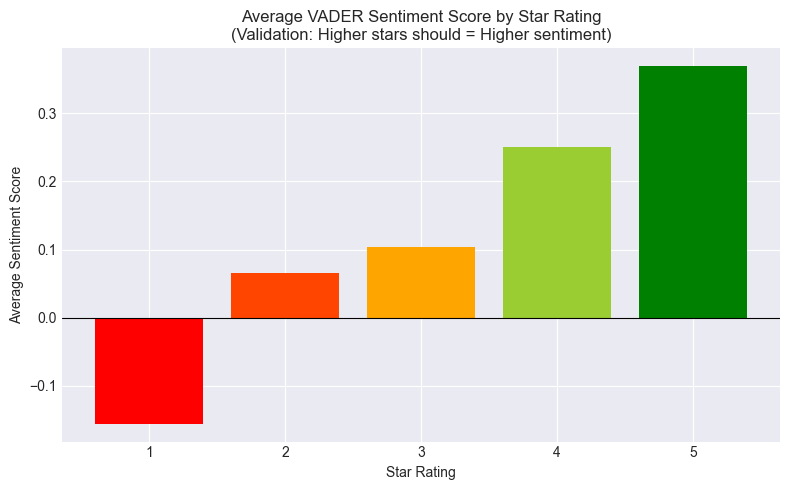

In [25]:
validation = df.groupby("rating")["sentiment_score"].mean().round(3)
print("Average sentiment score by star rating:")
print(validation)
print("\nExpected: scores should increase as rating increases")

# Plot validation
plt.figure(figsize=(8, 5))
plt.bar(validation.index, validation.values, 
        color=['red','orangered','orange','yellowgreen','green'])
plt.title("Average VADER Sentiment Score by Star Rating\n(Validation: Higher stars should = Higher sentiment)")
plt.xlabel("Star Rating")
plt.ylabel("Average Sentiment Score")
plt.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig("notebooks/sentiment_validation.png")
plt.show()

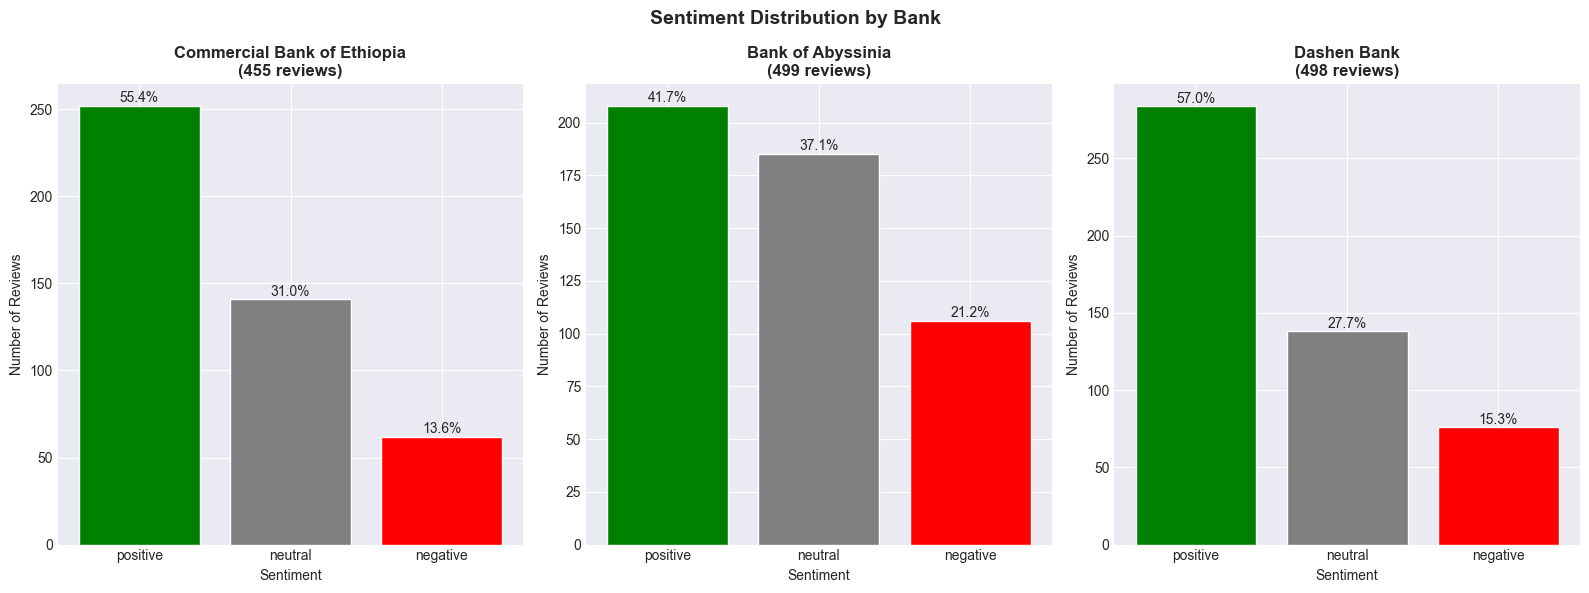

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
banks = df["bank"].unique()
colors = {"positive": "green", "neutral": "gray", "negative": "red"}

for i, bank in enumerate(banks):
    bank_df = df[df["bank"] == bank]
    counts = bank_df["sentiment_label"].value_counts()
    
    axes[i].bar(counts.index, counts.values,
                color=[colors.get(l, "blue") for l in counts.index],
                edgecolor="white")
    axes[i].set_title(f"{bank}\n({len(bank_df)} reviews)", fontweight='bold')
    axes[i].set_ylabel("Number of Reviews")
    axes[i].set_xlabel("Sentiment")
    
    # Add percentage labels
    total = len(bank_df)
    for j, (label, count) in enumerate(counts.items()):
        axes[i].text(j, count + 2, f"{count/total*100:.1f}%", 
                    ha='center', fontsize=10)

plt.suptitle("Sentiment Distribution by Bank", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("notebooks/sentiment_by_bank.png")
plt.show()

## Sentiment Interpretation

Interpret what the numbers mean for each bank's product team.

In [27]:
summary = df.groupby("bank").agg(
    Total_Reviews=("review", "count"),
    Avg_Sentiment=("sentiment_score", "mean"),
    Avg_Rating=("rating", "mean"),
    Positive_Pct=("sentiment_label", lambda x: (x=="positive").mean()*100),
    Negative_Pct=("sentiment_label", lambda x: (x=="negative").mean()*100),
    Neutral_Pct=("sentiment_label", lambda x: (x=="neutral").mean()*100)
).round(2)

print("Sentiment Summary by Bank:")
print(summary.to_string())

Sentiment Summary by Bank:
                             Total_Reviews  Avg_Sentiment  Avg_Rating  Positive_Pct  Negative_Pct  Neutral_Pct
bank                                                                                                          
Bank of Abyssinia                      499           0.11        3.28         41.68         21.24        37.07
Commercial Bank of Ethiopia            455           0.23        3.94         55.38         13.63        30.99
Dashen Bank                            498           0.26        3.78         57.03         15.26        27.71


## Step 2: Thematic Analysis

We extract the most significant keywords per bank using TF-IDF,
then group them into 5 business-relevant themes:

| Theme | Example Keywords |
|-------|-----------------|
| Account Access Issues | login, password, otp, fingerprint, verify |
| Transaction Performance | transfer, slow, fast, payment, send, money |
| App Stability | crash, error, bug, update, fix, freeze |
| UI & User Experience | easy, simple, good, design, interface, navigation |
| Customer Support | support, service, response, call, help, agent |

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Custom stop words for banking context
banking_stopwords = [
    'app', 'bank', 'banking', 'cbe', 'boa', 'dashen', 'ethiopia',
    'mobile', 'use', 'using', 'used', 'just', 'like', 'get', 'got',
    'good', 'bad', 'please', 'thank', 'thanks', 'need', 'want',
    'really', 'very', 'so', 'the', 'and', 'or', 'is', 'are', 'was'
]

keywords_by_bank = {}

for bank in df["bank"].unique():
    bank_reviews = df[df["bank"] == bank]["review"].fillna("")
    
    vectorizer = TfidfVectorizer(
        max_features=50,
        stop_words='english',
        ngram_range=(1, 2),
        min_df=2
    )
    
    try:
        X = vectorizer.fit_transform(bank_reviews)
        scores = X.toarray().sum(axis=0)
        keywords = pd.Series(scores, index=vectorizer.get_feature_names_out())
        keywords = keywords.sort_values(ascending=False).head(20)
        keywords_by_bank[bank] = keywords
        
        print(f"\n{bank} — Top 20 Keywords:")
        print(keywords.to_string())
    except Exception as e:
        print(f"Error for {bank}: {e}")


Commercial Bank of Ethiopia — Top 20 Keywords:
app            59.661983
good           46.284643
nice           20.671850
best           19.135285
cbe            17.981017
bank           15.675506
like           14.802221
application    14.430345
update         13.789148
working        13.339737
work           12.766562
use            12.495922
service        12.324452
fast           11.144816
transfer       11.045808
easy           10.285582
great           8.852735
excellent       8.286859
nice app        7.828674
ነው              7.408146

Bank of Abyssinia — Top 20 Keywords:
app            76.850636
good           36.881193
best           24.687505
bank           24.174138
boa            22.587343
working        16.374232
work           15.958114
banking        14.809005
mobile         14.344558
use            14.114336
worst          13.214776
fast           13.143631
like           12.129714
nice           11.729182
update         11.403728
doesn          11.031638
time          

In [29]:
# Define theme keywords
theme_keywords = {
    "Account Access Issues": [
        "login", "password", "otp", "fingerprint", "verify", 
        "verification", "sign", "access", "account", "pin", "locked"
    ],
    "Transaction Performance": [
        "transfer", "slow", "fast", "payment", "send", "money",
        "transaction", "speed", "quick", "delay", "pending", "failed"
    ],
    "App Stability": [
        "crash", "error", "bug", "update", "fix", "freeze", 
        "problem", "issue", "work", "open", "load", "loading"
    ],
    "UI & User Experience": [
        "easy", "simple", "design", "interface", "navigation",
        "nice", "beautiful", "user", "friendly", "convenient", "smooth"
    ],
    "Customer Support": [
        "support", "service", "response", "call", "help", 
        "agent", "staff", "customer", "contact", "solve"
    ]
}

def assign_theme(review):
    """Assign the most relevant theme based on keyword matching."""
    if not isinstance(review, str):
        return "General Feedback"
    
    review_lower = review.lower()
    theme_scores = {}
    
    for theme, keywords in theme_keywords.items():
        score = sum(1 for kw in keywords if kw in review_lower)
        theme_scores[theme] = score
    
    best_theme = max(theme_scores, key=theme_scores.get)
    if theme_scores[best_theme] == 0:
        return "General Feedback"
    return best_theme

df["identified_theme"] = df["review"].apply(assign_theme)

print("Theme distribution:")
print(df["identified_theme"].value_counts())
print("\nTheme by bank:")
print(df.groupby("bank")["identified_theme"].value_counts())

Theme distribution:
identified_theme
General Feedback           830
App Stability              232
Transaction Performance    158
UI & User Experience       122
Account Access Issues       67
Customer Support            43
Name: count, dtype: int64

Theme by bank:
bank                         identified_theme       
Bank of Abyssinia            General Feedback           293
                             App Stability              103
                             Transaction Performance     47
                             Account Access Issues       22
                             UI & User Experience        20
                             Customer Support            14
Commercial Bank of Ethiopia  General Feedback           259
                             App Stability               69
                             Transaction Performance     56
                             UI & User Experience        40
                             Customer Support            18
                      

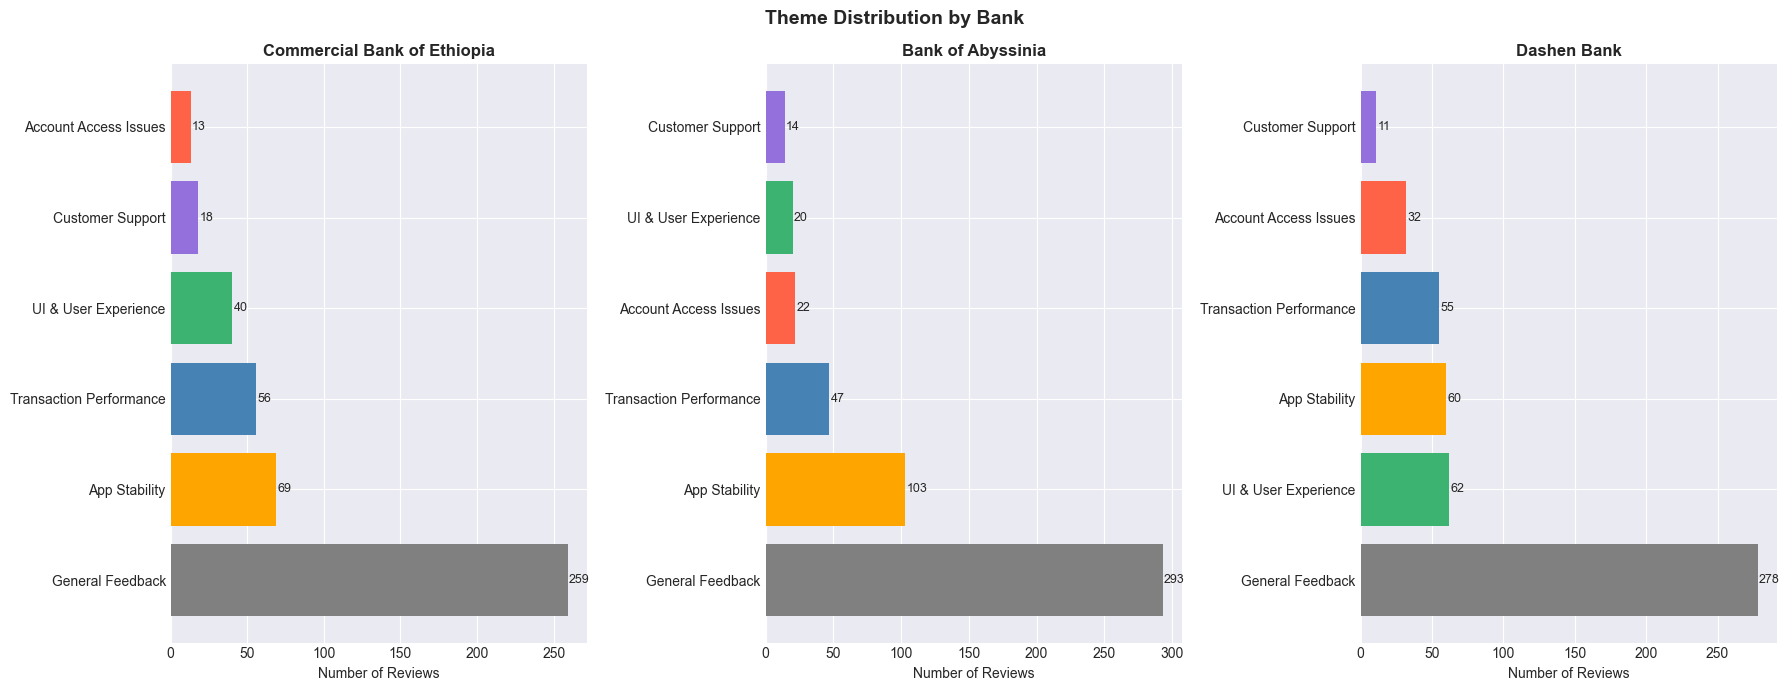

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
banks = df["bank"].unique()
theme_colors = {
    "Account Access Issues": "tomato",
    "Transaction Performance": "steelblue", 
    "App Stability": "orange",
    "UI & User Experience": "mediumseagreen",
    "Customer Support": "mediumpurple",
    "General Feedback": "gray"
}

for i, bank in enumerate(banks):
    bank_df = df[df["bank"] == bank]
    theme_counts = bank_df["identified_theme"].value_counts()
    
    colors = [theme_colors.get(t, "gray") for t in theme_counts.index]
    axes[i].barh(theme_counts.index, theme_counts.values, color=colors)
    axes[i].set_title(f"{bank}", fontweight='bold')
    axes[i].set_xlabel("Number of Reviews")
    
    for j, val in enumerate(theme_counts.values):
        axes[i].text(val + 1, j, str(val), va='center', fontsize=9)

plt.suptitle("Theme Distribution by Bank", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("notebooks/theme_by_bank.png")
plt.show()

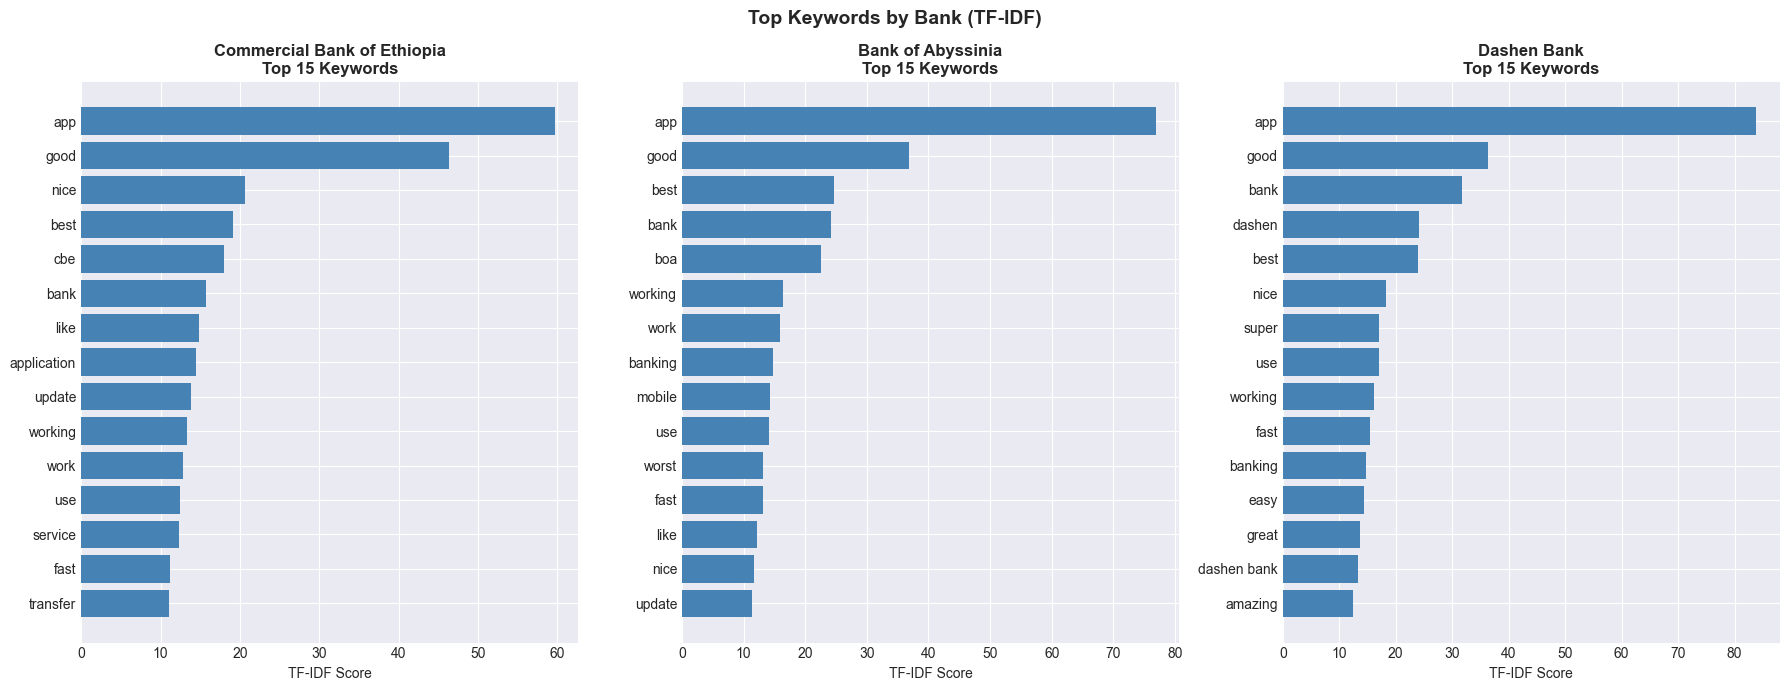

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for i, bank in enumerate(df["bank"].unique()):
    kw = keywords_by_bank[bank].head(15)
    axes[i].barh(kw.index[::-1], kw.values[::-1], color="steelblue")
    axes[i].set_title(f"{bank}\nTop 15 Keywords", fontweight='bold')
    axes[i].set_xlabel("TF-IDF Score")

plt.suptitle("Top Keywords by Bank (TF-IDF)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("notebooks/keywords_by_bank.png")
plt.show()

In [32]:
# Add review_id column
df.insert(0, "review_id", range(1, len(df) + 1))

# Save enriched dataset
output_cols = ["review_id", "review", "rating", "date", "bank", 
               "source", "sentiment_label", "sentiment_score", "identified_theme"]
df[output_cols].to_csv("data/raw/bank_reviews_analyzed.csv", index=False)

print(f"Saved {len(df)} analyzed reviews to data/raw/bank_reviews_analyzed.csv")
print("\nFinal dataset columns:")
print(df[output_cols].head())

Saved 1452 analyzed reviews to data/raw/bank_reviews_analyzed.csv

Final dataset columns:
   review_id                         review  rating        date  \
0          1                     incredible       5  2026-05-14   
1          2  best app for financial sector       5  2026-05-14   
2          3        it's a good application       5  2026-05-13   
3          4                  thank you cbe       5  2026-05-13   
4          5                        is good       5  2026-05-13   

                          bank       source sentiment_label  sentiment_score  \
0  Commercial Bank of Ethiopia  Google Play         neutral           0.0000   
1  Commercial Bank of Ethiopia  Google Play        positive           0.6369   
2  Commercial Bank of Ethiopia  Google Play        positive           0.4404   
3  Commercial Bank of Ethiopia  Google Play        positive           0.3612   
4  Commercial Bank of Ethiopia  Google Play        positive           0.4404   

   identified_theme  
0  G

In [33]:
def modular_nlp_pipeline(text):
    """
    Modular NLP preprocessing pipeline:
    1. Clean text (remove non-alphabetic characters)
    2. Tokenize
    3. Remove stop words
    4. Lemmatize
    """
    # 1. Cleaning
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())
    # 2. Tokenization
    tokens = word_tokenize(text)
    # 3. Stop-word removal & Lemmatization
    processed = [lemmatizer.lemmatize(t) for t in tokens 
                 if t not in stop_words and len(t) > 2]
    return " ".join(processed)

print("Applying modular NLP pipeline...")
df["clean_text"] = df["review"].apply(modular_nlp_pipeline)
df = df[df["clean_text"].str.len() > 2].copy()
print(f"Processed {len(df)} reviews")
df[["review", "clean_text"]].head(3)

Applying modular NLP pipeline...
Processed 1350 reviews


,review,clean_text
0,incredible,incredible
1,best app for financial sector,best app financial sector
2,it's a good application,good application


In [34]:
# Add TextBlob polarity and subjectivity
df["tb_polarity"] = df["review"].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity)
df["tb_subjectivity"] = df["review"].apply(
    lambda x: TextBlob(str(x)).sentiment.subjectivity)

def get_tb_label(s):
    return 'positive' if s >= 0.05 else ('negative' if s <= -0.05 else 'neutral')

df["tb_label"] = df["tb_polarity"].apply(get_tb_label)

print("VADER Distribution:")
print(df["sentiment_label"].value_counts(normalize=True).round(2))
print("\nTextBlob Distribution:")
print(df["tb_label"].value_counts(normalize=True).round(2))

VADER Distribution:
sentiment_label
positive    0.55
neutral     0.27
negative    0.18
Name: proportion, dtype: float64

TextBlob Distribution:
tb_label
positive    0.56
neutral     0.31
negative    0.14
Name: proportion, dtype: float64


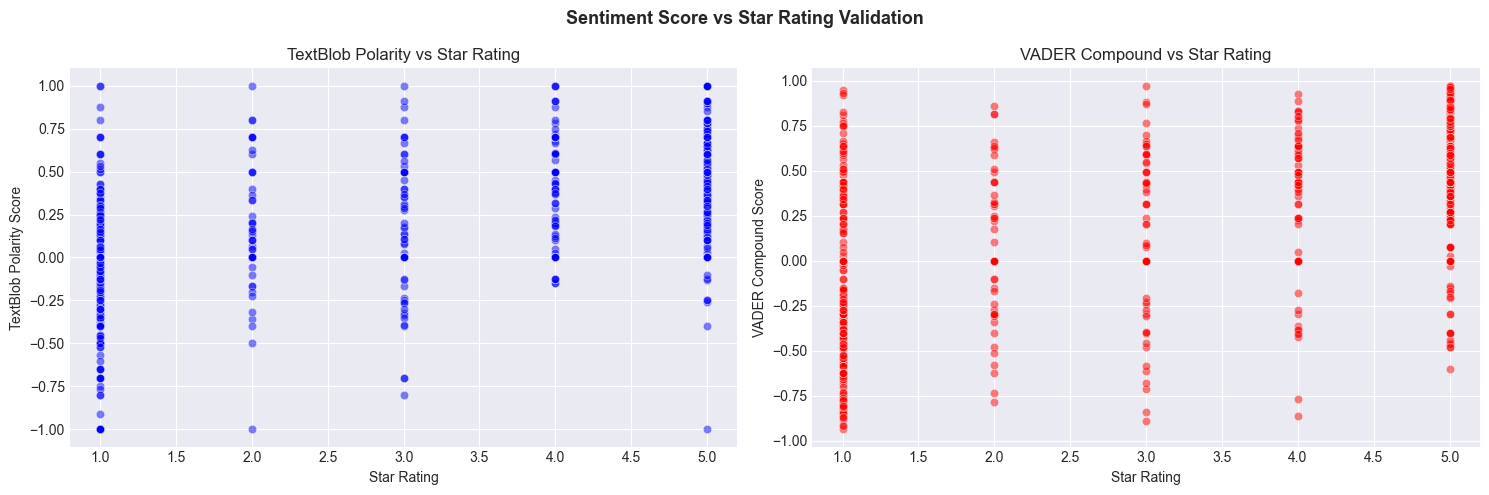

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# TextBlob Scatter
sns.scatterplot(data=df, x='rating', y='tb_polarity', 
                alpha=0.5, ax=axes[0], color='blue')
axes[0].set_title('TextBlob Polarity vs Star Rating')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('TextBlob Polarity Score')

# VADER Scatter
sns.scatterplot(data=df, x='rating', y='sentiment_score',
                alpha=0.5, ax=axes[1], color='red')
axes[1].set_title('VADER Compound vs Star Rating')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('VADER Compound Score')

plt.suptitle("Sentiment Score vs Star Rating Validation", 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("notebooks/sentiment_scatter_validation.png")
plt.show()

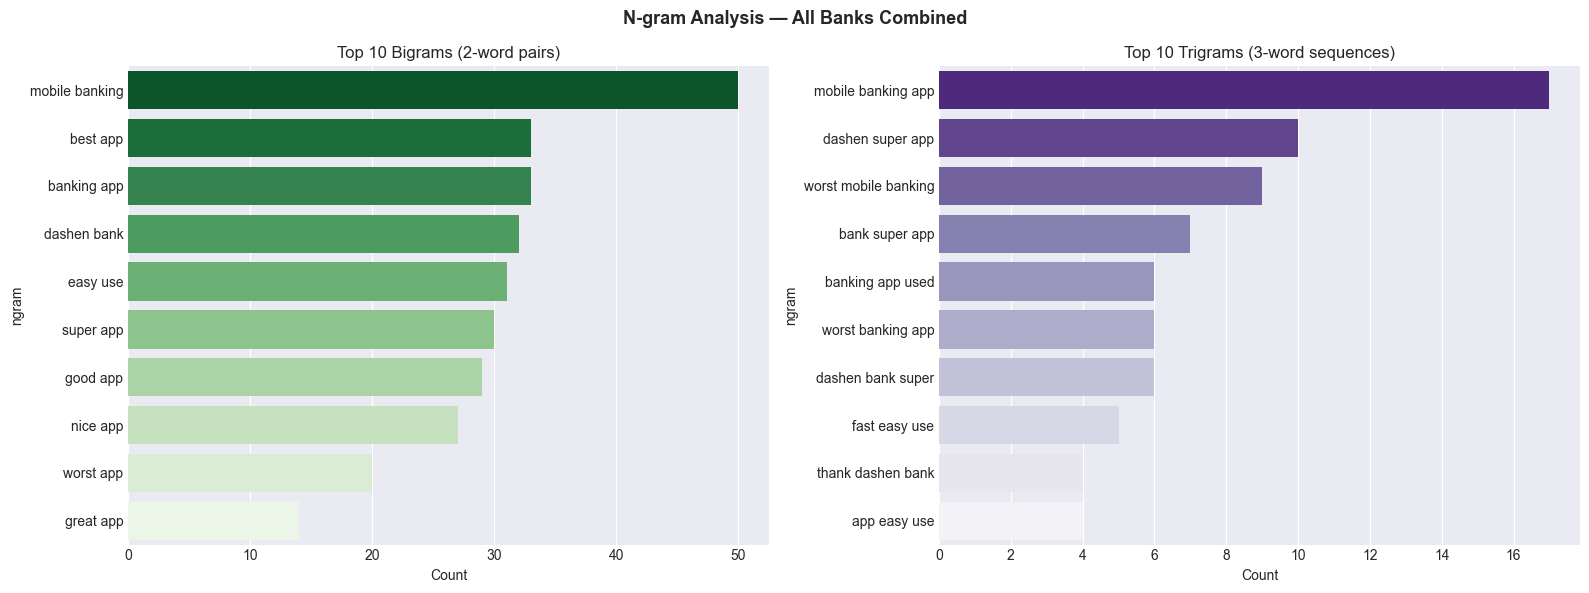

In [36]:
def get_top_ngrams(corpus, n, k=10):
    """Extract top n-grams from corpus."""
    vec = CountVectorizer(ngram_range=(n, n), max_features=100,
                          stop_words='english')
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    return pd.DataFrame({
        'ngram': vec.get_feature_names_out(),
        'count': counts
    }).sort_values('count', ascending=False).head(k)

from sklearn.feature_extraction.text import CountVectorizer

bi = get_top_ngrams(df["clean_text"], 2)
tri = get_top_ngrams(df["clean_text"], 3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=bi, x='count', y='ngram', ax=axes[0], palette='Greens_r')
axes[0].set_title('Top 10 Bigrams (2-word pairs)')
axes[0].set_xlabel('Count')

sns.barplot(data=tri, x='count', y='ngram', ax=axes[1], palette='Purples_r')
axes[1].set_title('Top 10 Trigrams (3-word sequences)')
axes[1].set_xlabel('Count')

plt.suptitle("N-gram Analysis — All Banks Combined",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("notebooks/ngrams_analysis.png")
plt.show()

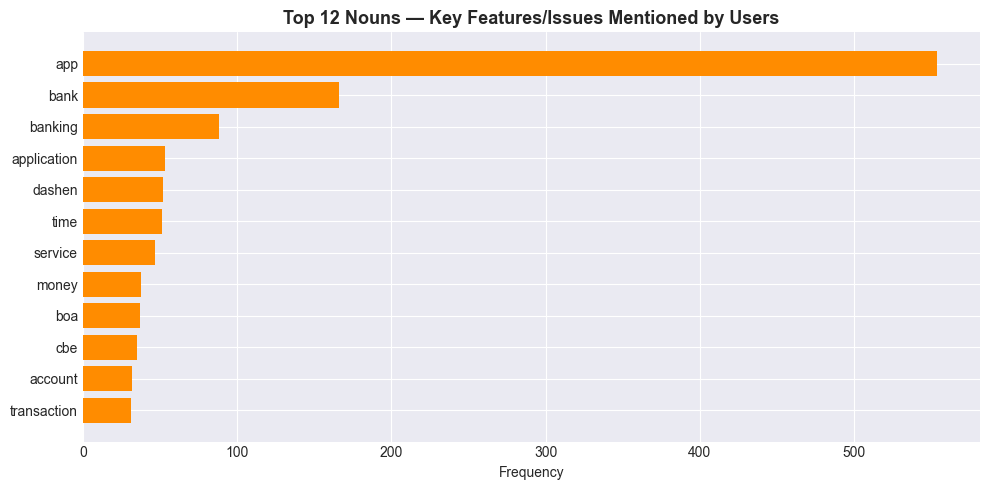

In [37]:
def extract_nouns(text):
    """Extract nouns as proxy for key product features mentioned."""
    try:
        tokens = word_tokenize(str(text))
        return [w.lower() for w, p in pos_tag(tokens) 
                if p.startswith('NN') and len(w) > 2 
                and w.lower() not in stop_words]
    except:
        return []

df["nouns"] = df["review"].apply(extract_nouns)
all_nouns = [n for ns in df["nouns"] for n in ns]
noun_counts = Counter(all_nouns).most_common(12)

plt.figure(figsize=(10, 5))
plt.barh([x[0] for x in noun_counts][::-1],
         [x[1] for x in noun_counts][::-1], color='darkorange')
plt.title('Top 12 Nouns — Key Features/Issues Mentioned by Users',
          fontsize=13, fontweight='bold')
plt.xlabel('Frequency')
plt.tight_layout()
plt.savefig("notebooks/top_nouns.png")
plt.show()

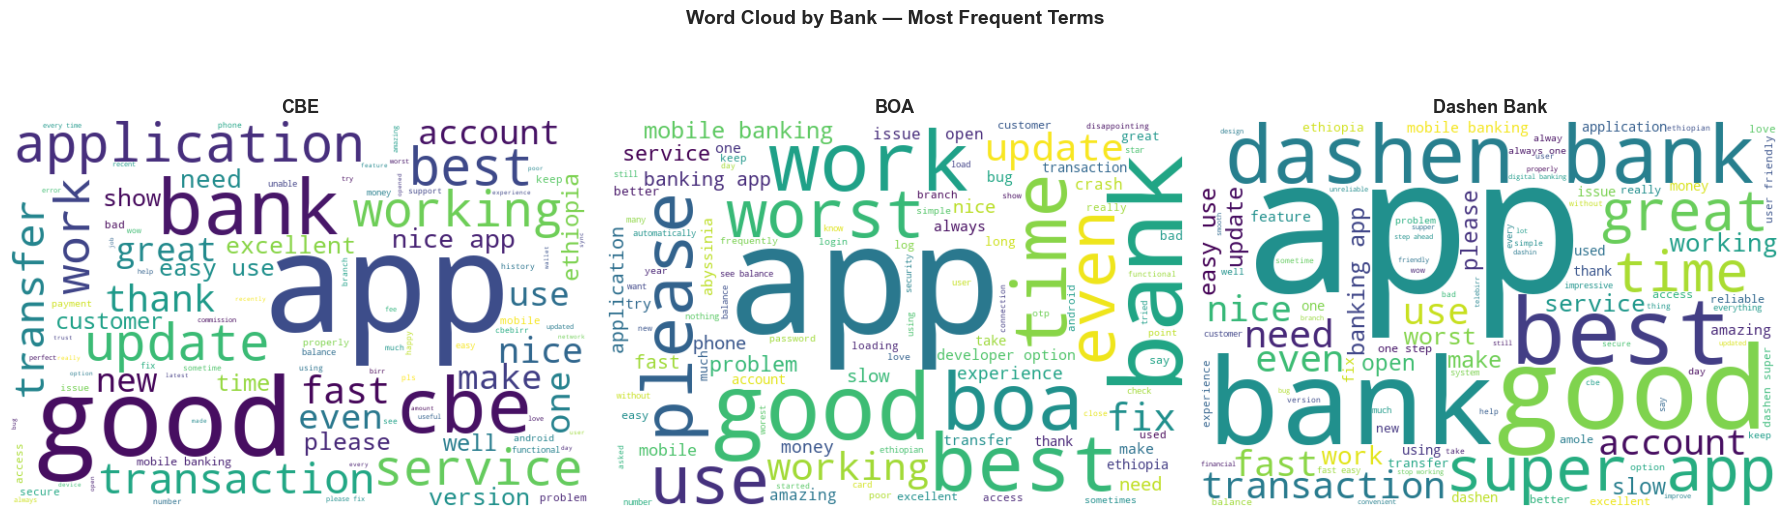

In [38]:
# Word cloud for each bank
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, bank in enumerate(df["bank"].unique()):
    bank_text = " ".join(df[df["bank"] == bank]["clean_text"])
    
    wc = WordCloud(
        width=600, height=400,
        background_color='white',
        colormap='viridis',
        max_words=100
    ).generate(bank_text)
    
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    short = bank.replace("Commercial Bank of Ethiopia","CBE").replace("Bank of Abyssinia","BOA")
    axes[i].set_title(f"{short}", fontsize=13, fontweight='bold')

plt.suptitle("Word Cloud by Bank — Most Frequent Terms",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("notebooks/wordclouds.png")
plt.show()

In [39]:
from tqdm.notebook import tqdm

try:
    from transformers import pipeline
    print("Loading DistilBERT model...")
    sent_model = pipeline(
        "sentiment-analysis",
        model="distilbert-base-uncased-finetuned-sst-2-english"
    )
    
    transformer_results = []
    batch_size = 16
    
    for i in tqdm(range(0, len(df), batch_size), 
                  desc="Running Transformer Sentiment"):
        batch = df["review"].iloc[i:i+batch_size].tolist()
        # Truncate long reviews to 512 tokens
        batch = [str(r)[:512] for r in batch]
        try:
            preds = sent_model(batch, truncation=True, max_length=512)
            transformer_results.extend(preds)
        except Exception as e:
            # Fill with neutral if batch fails
            transformer_results.extend(
                [{'label': 'NEUTRAL', 'score': 0.5}] * len(batch))
    
    df["transformer_label"] = [p['label'] for p in transformer_results]
    df["transformer_score"] = [
        p['score'] if p['label'] == 'POSITIVE' else -p['score'] 
        for p in transformer_results
    ]
    
    print("\nTransformer Distribution:")
    print(df["transformer_label"].value_counts(normalize=True).round(2))

except Exception as e:
    print(f"Transformer skipped: {e}")
    df["transformer_label"] = "N/A"
    df["transformer_score"] = 0.0

Loading DistilBERT model...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Running Transformer Sentiment:   0%|          | 0/85 [00:00<?, ?it/s]


Transformer Distribution:
transformer_label
POSITIVE    0.56
NEGATIVE    0.44
Name: proportion, dtype: float64


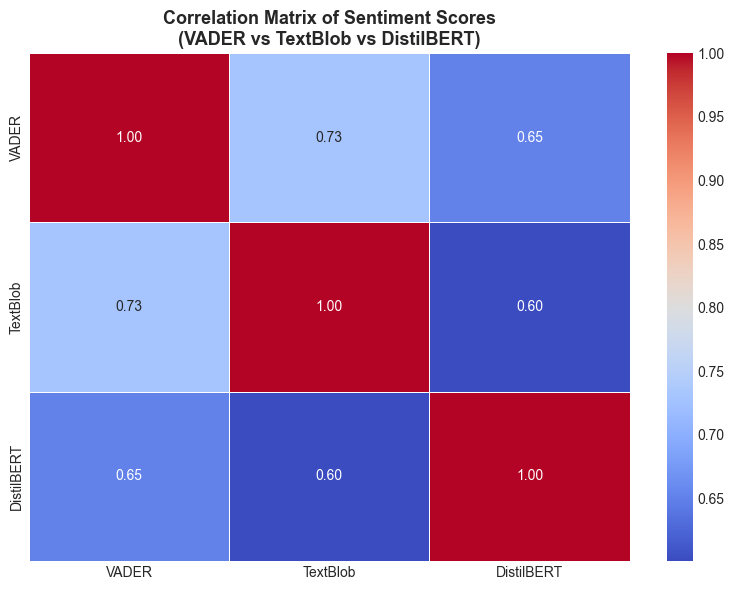


Interpretation:
Higher correlation = tools agree on sentiment direction
VADER and DistilBERT typically correlate well on English text


In [40]:
if "transformer_score" in df.columns and df["transformer_score"].dtype != object:
    sentiment_scores = df[["sentiment_score", "tb_polarity", "transformer_score"]]
    sentiment_scores.columns = ["VADER", "TextBlob", "DistilBERT"]
    
    corr_matrix = sentiment_scores.corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', 
                fmt=".2f", linewidths=0.5)
    plt.title("Correlation Matrix of Sentiment Scores\n(VADER vs TextBlob vs DistilBERT)",
              fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig("notebooks/sentiment_correlation_heatmap.png")
    plt.show()
    
    print("\nInterpretation:")
    print("Higher correlation = tools agree on sentiment direction")
    print("VADER and DistilBERT typically correlate well on English text")
else:
    print("Transformer scores not available — skipping correlation heatmap")

Average VADER Sentiment by Bank and Star Rating:
rating                           1      2      3      4      5
bank                                                          
Bank of Abyssinia           -0.195  0.007  0.182  0.292  0.344
Commercial Bank of Ethiopia -0.097  0.212 -0.075  0.207  0.395
Dashen Bank                 -0.167  0.043  0.261  0.366  0.447


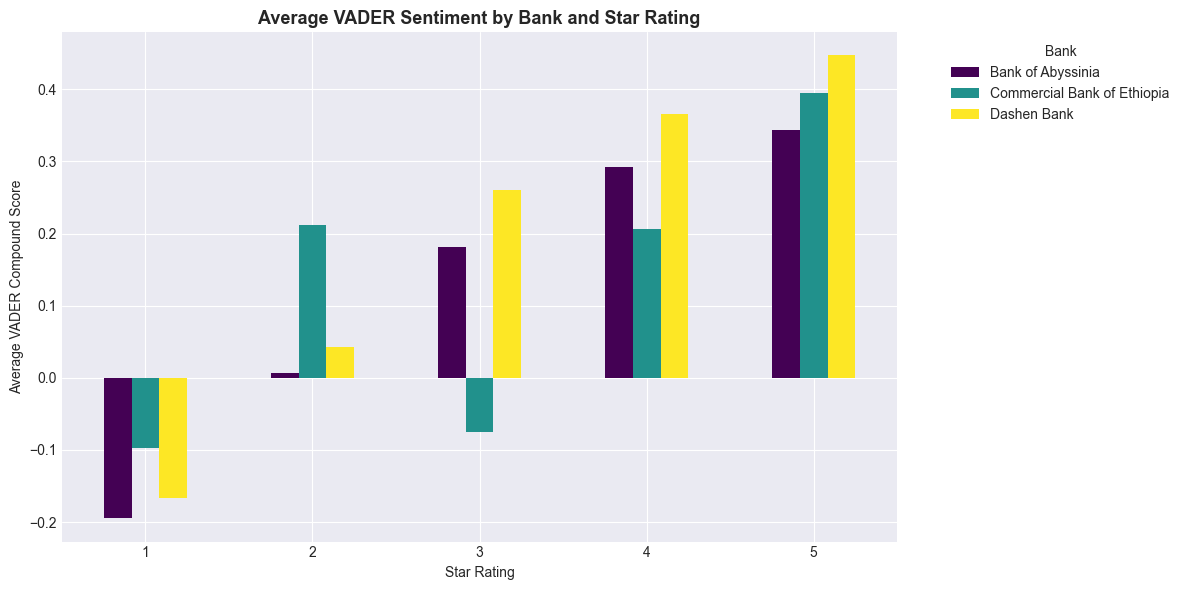

In [41]:
print("Average VADER Sentiment by Bank and Star Rating:")
vader_agg = df.groupby(["bank", "rating"])["sentiment_score"].mean().unstack().round(3)
print(vader_agg)

# Plot
vader_agg.T.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title("Average VADER Sentiment by Bank and Star Rating",
          fontsize=13, fontweight='bold')
plt.xlabel("Star Rating")
plt.ylabel("Average VADER Compound Score")
plt.xticks(rotation=0)
plt.legend(title='Bank', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig("notebooks/vader_by_bank_rating.png")
plt.show()

In [42]:
# Save updated dataset with all new columns
output_cols = ["review_id", "review", "rating", "date", "bank", "source",
               "clean_text", "sentiment_label", "sentiment_score",
               "tb_polarity", "tb_label", "identified_theme"]

df[output_cols].to_csv("data/raw/bank_reviews_analyzed.csv", index=False)
print(f"Updated CSV saved with {len(df)} reviews and enhanced analysis")
print("New columns added: clean_text, tb_polarity, tb_label")

Updated CSV saved with 1350 reviews and enhanced analysis
New columns added: clean_text, tb_polarity, tb_label
